In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
df = pd.read_csv("diabetes.csv")

In [3]:

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:

df.shape

(768, 9)

In [5]:

df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [6]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Exploratory Data Analysis (EDA)

In [10]:

df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

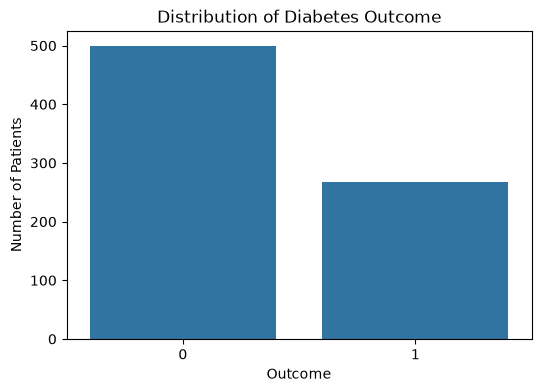

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="Outcome", data=df)

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

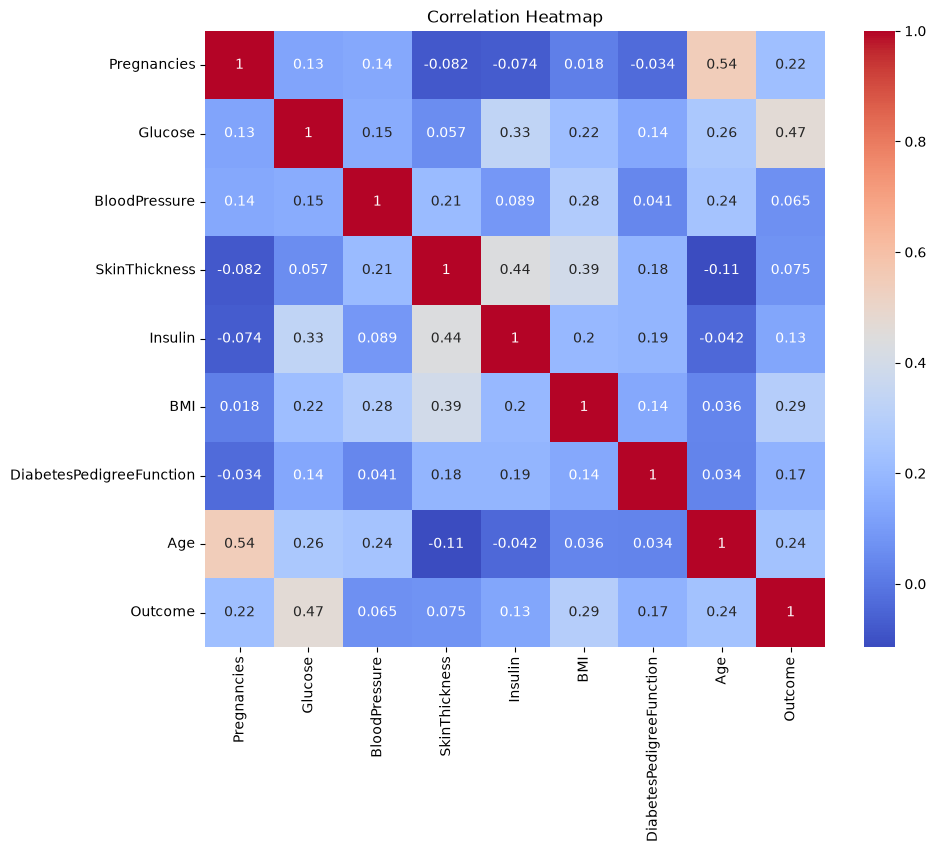

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [13]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

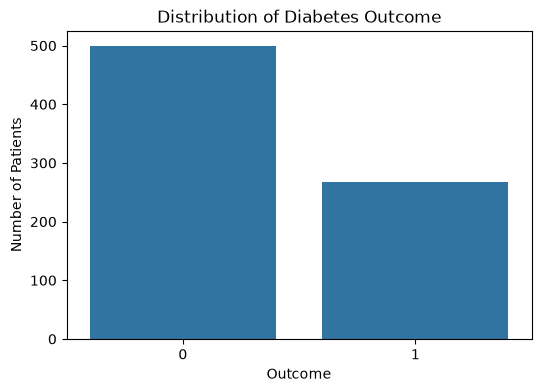

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="Outcome", data=df)

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

Preprocessing

In [16]:
# Separate Features (X) and Target (y)

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [17]:
print(X.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  


In [18]:
print(y.head())

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [19]:
print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [20]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

In [21]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


Feature Scaling using StandardScaler

In [22]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test = scaler.transform(X_test)

In [23]:
X_train = scaler.fit_transform(X_train)

In [24]:
print(X_train)

[[-0.85811767  0.06488386  0.25332145 ... -0.51313743 -1.10316947
  -0.27704152]
 [-0.85811767 -0.84697246  0.66358026 ...  0.4081093  -0.71238555
   0.84376203]
 [-1.15412006 -0.87841578  0.04819205 ...  1.49569224 -0.37742791
  -1.05298243]
 ...
 [ 0.02988949  0.09632718  0.04819205 ... -0.3723914   1.96433735
   1.01619334]
 [-0.2661129  -0.18666271  0.25332145 ... -0.70506383 -1.08260189
  -0.79433546]
 [ 0.02988949 -0.37532264 -0.15693736 ...  0.0114614  -0.01308802
  -0.36325717]]


In [25]:
# Import Support Vector Classifier
from sklearn.svm import SVC

# Create the SVM model
classifier = SVC(kernel='linear')

# Train the model
classifier.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [26]:
# Predict on test data
X_test_prediction = classifier.predict(X_test)

In [30]:
print(classification_report(y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       109
           1       0.63      0.49      0.55        45

    accuracy                           0.77       154
   macro avg       0.72      0.68      0.70       154
weighted avg       0.75      0.77      0.76       154



In [27]:
from sklearn.metrics import accuracy_score

test_data_accuracy = accuracy_score(y_test, X_test_prediction)

print("Accuracy Score:", test_data_accuracy)

Accuracy Score: 0.7662337662337663


Confusion Matrix

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, X_test_prediction)

print(cm)

[[96 13]
 [23 22]]


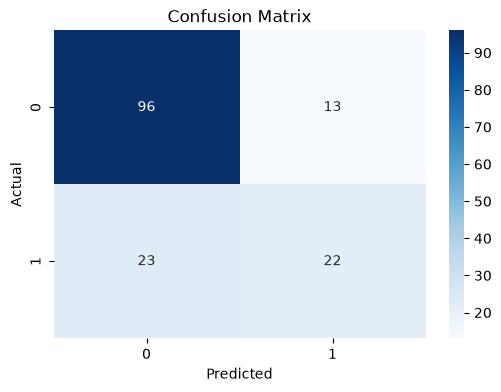

In [29]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Real-Time Prediction System

In [31]:
# Example patient data

input_data = (6,148,72,35,0,33.6,0.627,50)
input_data_as_numpy_array = np.asarray(input_data)

In [32]:
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

In [33]:
input_data_scaled = scaler.transform(input_data_reshaped)

In [34]:
prediction = classifier.predict(input_data_scaled)

print(prediction)

[1]


In [35]:
if prediction[0] == 0:
    print("The patient is not diabetic")
else:
    print("The patient is diabetic")

The patient is diabetic


In [36]:
import joblib

In [37]:
joblib.dump(classifier, "diabetes_model.pkl")

['diabetes_model.pkl']

In [38]:
loaded_model = joblib.load("diabetes_model.pkl")

In [39]:
prediction = loaded_model.predict(input_data_scaled)

print(prediction)

[1]
